## Data Cleaning & Tidy Process

The dataset is first loaded using read_csv(). Then melt() reshapes the data from a wide format to a long format so each department-year observation can be stored in its own row.

In [2]:
import pandas as pd
Fed_RD = pd.read_csv("data/fed_rd_year&gdp.csv")
Fed_RD = pd.melt(Fed_RD, id_vars=['department'], var_name='year_gdp', value_name='gdp_value')
pd.set_option('display.max_columns', None)
Fed_RD


,department,year_gdp,gdp_value
0,DHS,1976_gdp1790000000000.0,NaN
1,DOC,1976_gdp1790000000000.0,8.190000e+08
2,DOD,1976_gdp1790000000000.0,3.569600e+10
3,DOE,1976_gdp1790000000000.0,1.088200e+10
4,DOT,1976_gdp1790000000000.0,1.142000e+09
...,...,...,...
583,NIH,2017_gdp19177000000000.0,3.305200e+10
584,NSF,2017_gdp19177000000000.0,6.040000e+09
585,Other,2017_gdp19177000000000.0,1.553000e+09
586,USDA,2017_gdp19177000000000.0,2.625000e+09


First, the year_gdp column is split into two separate columns using str.split(). The str.replace() function removes the text "gdp" so the column only contains the actual, numeric GDP value. Finally, the extra columns that are no longer needed are removed so the dataset is organized in a tidy format where each variable has its own column.

In [3]:
Fed_RD[['year', 'gdp']] = Fed_RD['year_gdp'].str.split('_', expand=True)
Fed_RD['gdp'] = Fed_RD['gdp'].str.replace('gdp', '')
Fed_RD = Fed_RD.drop(columns=['year_gdp', 'gdp'])
Fed_RD

,department,gdp_value,year
0,DHS,NaN,1976
1,DOC,8.190000e+08,1976
2,DOD,3.569600e+10,1976
3,DOE,1.088200e+10,1976
4,DOT,1.142000e+09,1976
...,...,...,...
583,NIH,3.305200e+10,2017
584,NSF,6.040000e+09,2017
585,Other,1.553000e+09,2017
586,USDA,2.625000e+09,2017


Final clean up of column names. Then changed the GDP and Year columns to numeric format. Finally, I changed the GDP out of scientific notation so it would be easier to read.

In [4]:
Fed_RD = Fed_RD.rename(columns={'department': 'Department', 'year': 'Year', 'gdp_value': 'GDP'})
Fed_RD['GDP'] = pd.to_numeric(Fed_RD['GDP'])
Fed_RD['Year'] = pd.to_numeric(Fed_RD['Year'])
pd.options.display.float_format = '{:,.0f}'.format
Fed_RD

,Department,GDP,Year
0,DHS,NaN,1976
1,DOC,"819,000,000",1976
2,DOD,"35,696,000,000",1976
3,DOE,"10,882,000,000",1976
4,DOT,"1,142,000,000",1976
...,...,...,...
583,NIH,"33,052,000,000",2017
584,NSF,"6,040,000,000",2017
585,Other,"1,553,000,000",2017
586,USDA,"2,625,000,000",2017


### Heatmap: GDP by Department and Year

This chart gives an overall comparison of GDP across departments over time. The color differences make it easier to see which departments consistently have higher GDP values and which remain lower across the full dataset.

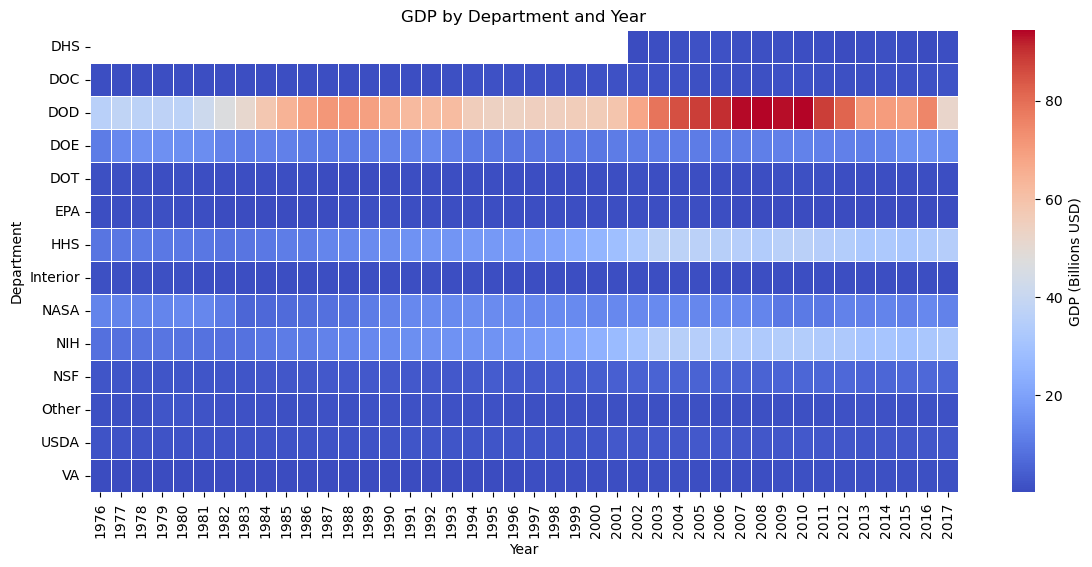

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_GDP = pd.pivot_table(Fed_RD, values='GDP', index='Department', columns='Year') / 1e9

plt.figure(figsize=(14,6))

ax = sns.heatmap(pivot_GDP, cmap="coolwarm", linewidths=0.5)

cbar = ax.collections[0].colorbar
cbar.set_label("GDP (Billions USD)")

plt.title("GDP by Department and Year")
plt.xlabel("Year")
plt.ylabel("Department")

plt.show()

### Heatmap: Last 10 Years of GDP by Department

This heatmap focuses only on the most recent 10 years in the dataset. The labeled values help compare year-to-year changes within each department and highlight where GDP increased or decreased in the most recent period.

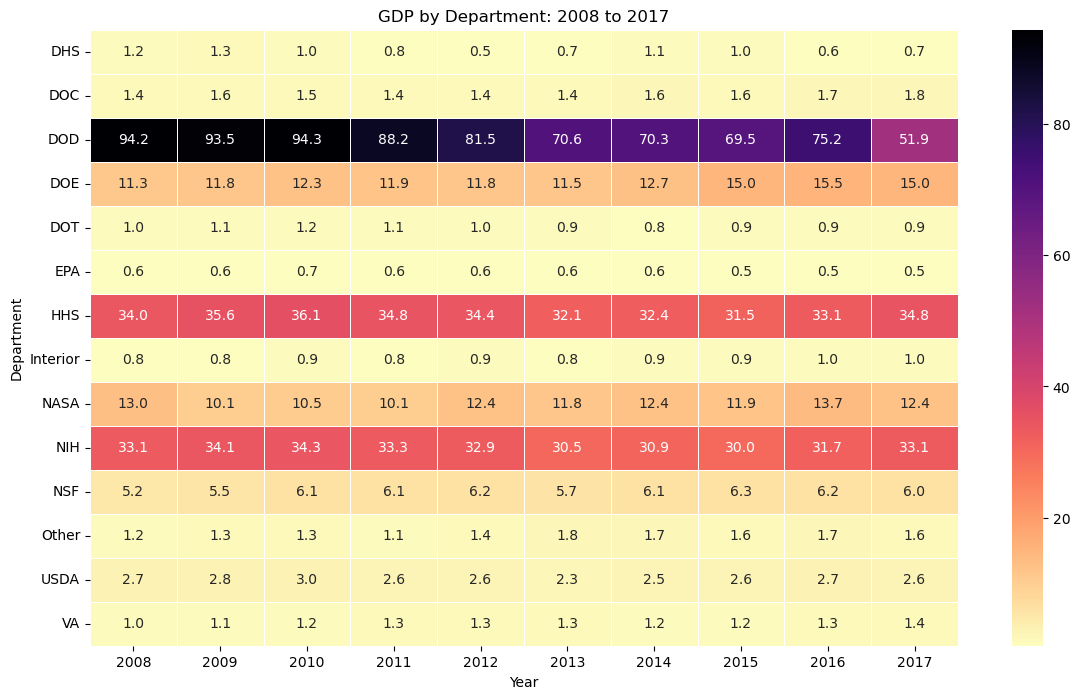

In [ ]:
# 1. Filter for the last 10 years dynamically
max_year = Fed_RD['Year'].max()
last_10_df = Fed_RD[Fed_RD['Year'] > (max_year - 10)]

# 2. Pivot the filtered data
pivot_GDP = pd.pivot_table(
    last_10_df,
    values='GDP',
    index='Department',
    columns='Year') / 1e9

# 4. Plot
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_GDP, annot=True, fmt=".1f", cmap="magma_r", linewidths=0.5)

plt.title(f"GDP by Department: {max_year-9} to {max_year}")
plt.show()

### Line Chart: GDP Trends for the Top 5 Departments

This graph follows the five departments with the highest average GDP across the dataset. A line chart works well here because it shows trend direction over time and makes it easier to compare which top departments stay highest, rise, or decline across the years.

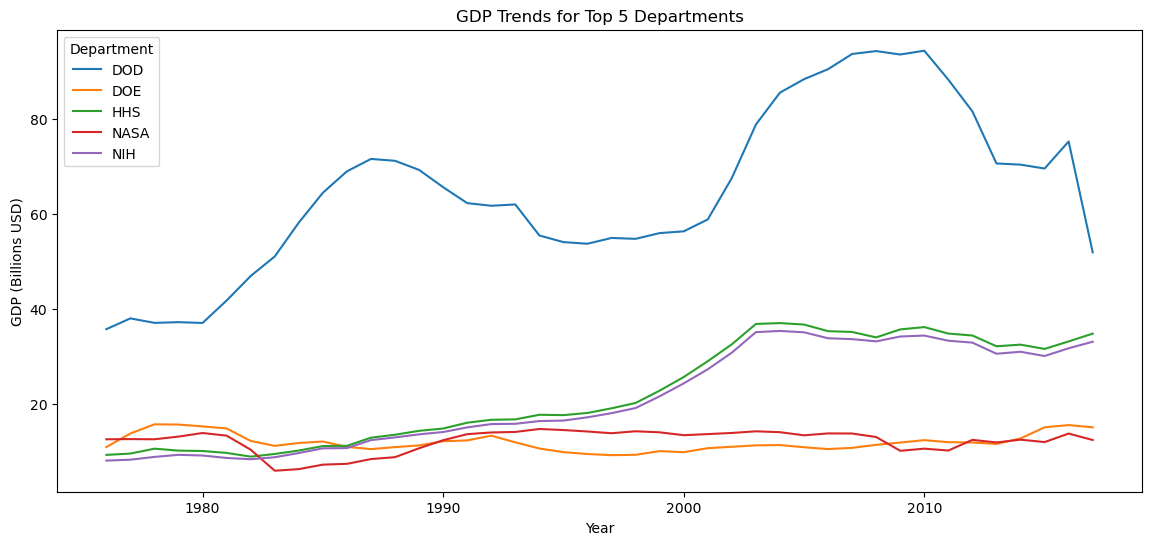

In [44]:
# Line graph of the last 10 years for departments with the highest AVG GDP
top_departments = Fed_RD.groupby('Department')['GDP'].mean().nlargest(5).index

# Filter for just the top 5 departments
filtered_df = Fed_RD[Fed_RD['Department'].isin(top_departments)]

plt.figure(figsize=(14,6))
sns.lineplot(data=filtered_df, x='Year', y=filtered_df['GDP'] / 1e9, hue='Department')

plt.title("GDP Trends for Top 5 Departments")
plt.ylabel("GDP (Billions USD)")
plt.show()

### Pivot Table: Average GDP by Department

This pivot table takes the mean GDP by department across all years. The department of defense on average had the largest GDP with an average of $64 billon. The lowest average GDP was roughly $733 million belonging to the department of Veterans Affairs.

In [137]:
pivot_table_GDP = pd.pivot_table(
    Fed_RD,
    values='GDP',
    index='Department',
    aggfunc='mean'
).sort_values(by='GDP', ascending=False)


pivot_table_GDP

,GDP
Department,
DOD,"64,685,190,476"
HHS,"22,296,761,905"
NIH,"21,117,571,429"
NASA,"12,140,261,905"
DOE,"11,883,380,952"
NSF,"4,038,809,524"
USDA,"2,380,809,524"
Other,"1,494,761,905"
DOC,"1,231,500,000"
